# 03 · Supervised technical validation (BPT 5204 damage classes)

Fine-tunes ResNet18 (headline) on the segmented BPT 5204 grains and evaluates it under a
**single, clearly-defined protocol**, then repeats the headline metric for extra
architectures. Written for the released, renamed dataset.


> **Trained models are cached as `.pth` files** under `Checkpoints/models/`. The first
> run trains and saves; later runs load from disk so you can regenerate any figure or
> table **without retraining**. Set `FORCE_RETRAIN = True` (or delete `Checkpoints/models/`)
> after you change the data, class set, or hyper-parameters.

### Evaluation protocol (read this — it is the paragraph to paraphrase into the paper)
1. **Balanced pool** — cap each class at `MAX_IMAGES_PER_CLASS` so no class dominates
   (Discolored has ~4× Broken). Selection is deterministic.
2. **Split**, *by grain-ID* so an original/segmented pair can never straddle partitions:
   * **Train / Val / Test = 70 / 15 / 15**.
   * **Val** selects the best epoch (checkpointing).
   * **Test** is untouched until the very end and is what the confusion matrix, per-class
     metrics, ROC and Grad-CAM are computed on. *Val and Test are different sets* — this
     removes the earlier "validation set doubling as the test set" weakness.
3. **5-fold Stratified-Group CV** on the pool → headline mean ± std accuracy / macro-F1
   (robustness to the partition).
4. **Multi-seed** re-runs of the fixed split → robustness to initialisation.


## Setup

In [1]:
import sys, os
for pth in (os.path.abspath("."), os.path.abspath("..")):
    if pth not in sys.path:
        sys.path.append(pth)

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import torch, torch.nn as nn
from torch.utils.data import DataLoader

import config as cfg
import rice_common as rc

rc.set_seed(cfg.SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "| seed:", cfg.SEED)

SUP_DIR = cfg.OUTPUT_DIR / "supervised"
SUP_DIR.mkdir(parents=True, exist_ok=True)

# Trained weights are cached here as .pth files. On a second run each model is
# loaded from disk instead of retrained, so you can regenerate figures/metrics
# without paying for training again.
CKPT_DIR = cfg.CHECKPOINT_DIR / "models"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Set True to ignore cached .pth files and train everything from scratch.
# IMPORTANT: also do this (or delete CKPT_DIR) after you change the dataset,
# the class set, or any hyper-parameter — otherwise stale weights are reused.
FORCE_RETRAIN = False

GrainDataset = rc.make_dataset_class()
train_tf, eval_tf = rc.make_transforms()

# ---- choose the class set for a run: rc.CLASSES_5 (headline) or rc.CLASSES_6 (new) ----
def prepare_pool(classes):
    rows, mm = rc.list_bpt(cfg.SEGMENTED_IMAGE_DIR, classes)
    assert mm == 0, f"{mm} folder/filename label mismatches — fix before training"
    pool = rc.balanced_subset(rows, classes, cfg.MAX_IMAGES_PER_CLASS)
    print(f"{len(classes)}-class pool: {len(pool)} imgs -> {dict(Counter(r[1] for r in pool))}")
    return pool

Device: cuda | seed: 42


## 1 · Reusable train / evaluate helpers

`train_one` trains with val-based checkpointing and returns the best state.
`evaluate` returns predictions, probabilities and labels for any loader.
Both are architecture-agnostic (via `rc.build_model`).

In [2]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize

def make_loader(rows, classes, tf, shuffle):
    return DataLoader(GrainDataset(rows, classes, tf),
                      batch_size=cfg.BATCH_SIZE, shuffle=shuffle, num_workers=0,
                      worker_init_fn=rc.seed_worker, generator=rc.torch_generator())

def _torch_load(path):
    # Load a checkpoint dict across torch versions (weights_only added in 1.13).
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

def train_one(train_rows, val_rows, classes, arch="resnet18", epochs=None, seed=None,
              verbose=True, ckpt_path=None):
    # --- reuse a cached checkpoint if present ---
    if ckpt_path is not None and not FORCE_RETRAIN and Path(ckpt_path).exists():
        model = rc.build_model(arch, len(classes)).to(device)
        ck = _torch_load(ckpt_path)
        model.load_state_dict(ck["state_dict"])
        if verbose:
            print(f"  [{arch}] loaded cached {Path(ckpt_path).name} "
                  f"(val_acc={ck.get('val_acc', float('nan')):.4f})")
        return model, ck.get("val_acc", float("nan")), ck.get("hist", [])

    if seed is not None:
        rc.set_seed(seed)
    epochs = epochs or cfg.NUM_EPOCHS
    model = rc.build_model(arch, len(classes)).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()

    tl = make_loader(train_rows, classes, train_tf, shuffle=True)
    vl = make_loader(val_rows,   classes, eval_tf,  shuffle=False)

    # best_acc, best_state, hist = -1.0, None, []
    # for ep in range(epochs):
    #     model.train()
    #     for x, y, _ in tqdm(tl, desc=f"{arch} ep{ep+1}/{epochs}", leave=False):
    #         opt.zero_grad()
    #         loss = crit(model(x.to(device)), y.to(device))
    #         loss.backward(); opt.step()
    #     sched.step()
    #     vp, _, vy = evaluate(model, vl)
    #     va = accuracy_score(vy, vp)
    #     hist.append(va)
    #     if va > best_acc:
    #         best_acc, best_state = va, {k: v.detach().cpu().clone()
    #                                     for k, v in model.state_dict().items()}
    best_acc, best_state, hist = -1.0, None, []
    import torch.nn.functional as F
    for ep in range(epochs):
        model.train()
        run_loss = run_correct = run_n = 0
        for x, y, *_ in tqdm(tl, desc=f"{arch} ep{ep+1}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x); loss = crit(out, y)
            loss.backward(); opt.step()
            run_loss += loss.item() * x.size(0)
            run_correct += (out.argmax(1) == y).sum().item()
            run_n += x.size(0)
        sched.step()
        tr_loss, tr_acc = run_loss / run_n, run_correct / run_n
        vp, vpr, vy = evaluate(model, vl)
        va = accuracy_score(vy, vp)
        try:
            v_loss = F.nll_loss(torch.log(torch.tensor(np.clip(vpr, 1e-9, 1), dtype=torch.float)),
                                torch.tensor(vy)).item()
        except Exception:
            v_loss = float("nan")
        hist.append({"train_loss": tr_loss, "val_loss": v_loss, "train_acc": tr_acc, "val_acc": va})
        if va > best_acc:
            best_acc, best_state = va, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  [{arch}] epoch {ep+1:2d}/{epochs}  val_acc={va:.4f}")
    model.load_state_dict(best_state)
    if ckpt_path is not None:
        torch.save({"state_dict": model.state_dict(), "classes": classes,
                    "arch": arch, "val_acc": best_acc, "hist": hist,
                    "seed": seed if seed is not None else cfg.SEED}, ckpt_path)
        if verbose:
            print(f"  saved checkpoint -> {ckpt_path}")
    return model, best_acc, hist

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    P, Y, PR = [], [], []
    for x, y, _ in loader:
        out = model(x.to(device))
        PR.append(torch.softmax(out, 1).cpu().numpy())
        P.extend(out.argmax(1).cpu().tolist()); Y.extend(y.tolist())
    return np.array(P), np.concatenate(PR), np.array(Y)

def split_train_val_test(pool, classes):
    y = np.array([classes.index(r[1]) for r in pool])
    g = np.array([r[2] for r in pool])
    # 15% test
    tv_idx, te_idx = next(GroupShuffleSplit(1, test_size=0.15,
                          random_state=cfg.SEED).split(y, y, g))
    # of the remaining 85%, take ~17.6% as val -> ~15% overall
    yv, gv = y[tv_idx], g[tv_idx]
    tr_rel, va_rel = next(GroupShuffleSplit(1, test_size=0.1765,
                          random_state=cfg.SEED).split(yv, yv, gv))
    tr_idx = tv_idx[tr_rel]; va_idx = tv_idx[va_rel]
    for a, b in [(tr_idx, va_idx), (tr_idx, te_idx), (va_idx, te_idx)]:
        assert set(g[a]).isdisjoint(set(g[b])), "grain-id leakage between splits!"
    pick = lambda idx: [pool[i] for i in idx]
    return pick(tr_idx), pick(va_idx), pick(te_idx)

## 2 · Headline run — ResNet18, single leakage-safe split

Runs the full protocol for a given class set and prints the **test-set** confusion matrix,
per-class precision/recall/F1 and macro ROC-AUC. Call it once for 5-class and once for
6-class.

5-class pool: 5000 imgs -> {'Full chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}
split -> train 3499  val 751  test 750
  [resnet18] loaded cached resnet18_5class_headline.pth (val_acc=0.9547)
best val acc: 0.9547

TEST accuracy=0.9653  macro-F1=0.9658

Per-class report (TEST):
              precision    recall  f1-score   support

 Full chalky      0.993     0.972     0.982       142
     Healthy      0.932     0.956     0.944       158
  Discolored      0.978     0.950     0.964       140
 Peck damage      0.965     0.979     0.972       140
      Broken      0.965     0.971     0.968       170

    accuracy                          0.965       750
   macro avg      0.967     0.965     0.966       750
weighted avg      0.966     0.965     0.965       750

macro one-vs-rest ROC-AUC (TEST): 0.9986


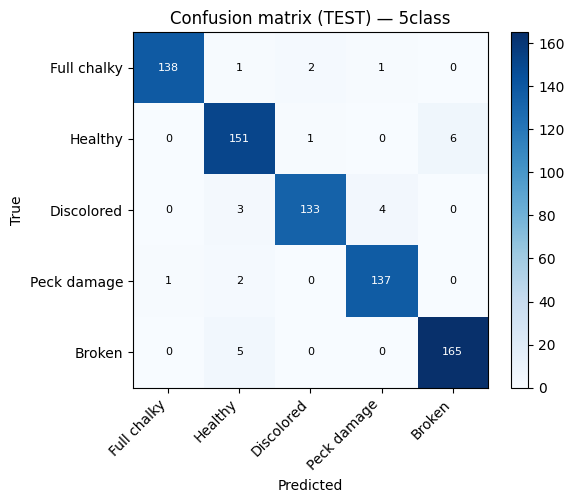

In [4]:
def headline_run(classes, arch="resnet18", tag="5class"):
    pool = prepare_pool(classes)
    tr, va, te = split_train_val_test(pool, classes)
    print(f"split -> train {len(tr)}  val {len(va)}  test {len(te)}")

    ckpt = CKPT_DIR / f"{arch}_{tag}_headline.pth"
    model, best_val, _ = train_one(tr, va, classes, arch=arch, verbose=True, ckpt_path=ckpt)
    print(f"best val acc: {best_val:.4f}")

    te_loader = make_loader(te, classes, eval_tf, shuffle=False)
    P, PR, Y = evaluate(model, te_loader)
    np.save(SUP_DIR / f"y_true_{tag}.npy", Y)
    np.save(SUP_DIR / f"y_pred_{tag}.npy", P)
    np.save(SUP_DIR / f"y_prob_{tag}.npy", PR)

    acc = accuracy_score(Y, P); mf1 = f1_score(Y, P, average="macro")
    print(f"\nTEST accuracy={acc:.4f}  macro-F1={mf1:.4f}")
    print("\nPer-class report (TEST):")
    print(classification_report(Y, P, labels=list(range(len(classes))),
                                target_names=classes, digits=3, zero_division=0))

    # one-vs-rest macro ROC-AUC
    Yb = label_binarize(Y, classes=list(range(len(classes))))
    present = [i for i in range(len(classes)) if Yb[:, i].sum() > 0]
    auc = roc_auc_score(Yb[:, present], PR[:, present], average="macro", multi_class="ovr")
    print(f"macro one-vs-rest ROC-AUC (TEST): {auc:.4f}")

    # confusion matrix figure
    cm = confusion_matrix(Y, P, labels=list(range(len(classes))))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right"); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion matrix (TEST) — {tag}")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
    fig.colorbar(im); fig.tight_layout()
    fig.savefig(SUP_DIR / f"confusion_{tag}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # save per-class metrics table
    rep = classification_report(Y, P, labels=list(range(len(classes))),
                                target_names=classes, output_dict=True, zero_division=0)
    import csv
    with open(SUP_DIR / f"per_class_metrics_{tag}.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["class", "precision", "recall", "f1", "support"])
        for cname in classes:
            d = rep[cname]
            w.writerow([cname, f"{d['precision']:.4f}", f"{d['recall']:.4f}",
                        f"{d['f1-score']:.4f}", int(d['support'])])
        w.writerow(["accuracy", "", "", f"{acc:.4f}", len(Y)])
        w.writerow(["macro_roc_auc", "", "", f"{auc:.4f}", ""])
    return dict(model=model, classes=classes, test=te, acc=acc, macro_f1=mf1, auc=auc)

res5 = headline_run(rc.CLASSES_5, arch="resnet18", tag="5class")

In [3]:
import csv
rows_out = []
for tag, classes in [("5class", rc.CLASSES_5), ("6class", rc.CLASSES_6)]:
    pool = prepare_pool(classes)
    tr, va, te = split_train_val_test(pool, classes)
    for split_name, subset in [("train", tr), ("val", va), ("test", te)]:
        for path, label, gid in subset:
            rows_out.append((tag, split_name, gid, label))
with open(SUP_DIR / "train_val_test_splits.csv", "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["class_set", "split", "grain_id", "class"])
    w.writerows(rows_out)
print("wrote", len(rows_out), "rows ->", SUP_DIR / "train_val_test_splits.csv")

5-class pool: 5000 imgs -> {'Full chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}
6-class pool: 6000 imgs -> {'Full chalky': 1000, 'Partial chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}
wrote 11000 rows -> Outputs\supervised\train_val_test_splits.csv


6-class pool: 6000 imgs -> {'Full chalky': 1000, 'Partial chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}
split -> train 4199  val 901  test 900
  [resnet18] loaded cached resnet18_6class_headline.pth (val_acc=0.9412)
best val acc: 0.9412

TEST accuracy=0.9522  macro-F1=0.9521

Per-class report (TEST):
                precision    recall  f1-score   support

   Full chalky      0.963     0.977     0.970       132
Partial chalky      0.905     0.911     0.908       146
       Healthy      0.926     0.914     0.920       151
    Discolored      0.966     0.971     0.968       173
   Peck damage      0.977     0.970     0.974       133
        Broken      0.976     0.970     0.973       165

      accuracy                          0.952       900
     macro avg      0.952     0.952     0.952       900
  weighted avg      0.952     0.952     0.952       900

macro one-vs-rest ROC-AUC (TEST): 0.9978


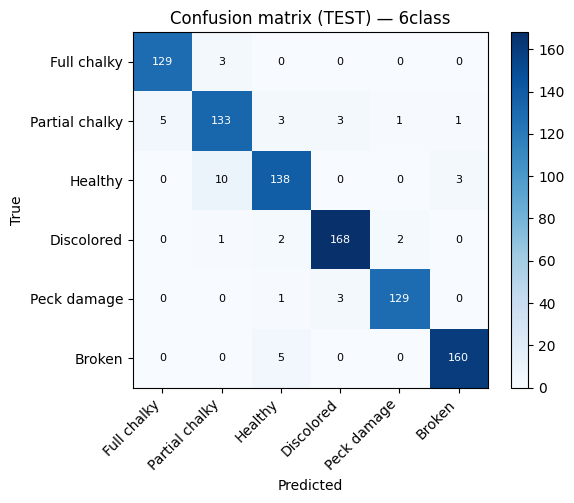


=== headline comparison ===
5-class: acc=0.9653  macroF1=0.9658  AUC=0.9986
6-class: acc=0.9522  macroF1=0.9521  AUC=0.9978
The accuracy gap and where the 6-class confusion concentrates (partial↔full chalky,
partial↔healthy) is the evidence that partial-chalky is a graded intermediate.


In [5]:
res6 = headline_run(rc.CLASSES_6, arch="resnet18", tag="6class")
print("\n=== headline comparison ===")
print(f"5-class: acc={res5['acc']:.4f}  macroF1={res5['macro_f1']:.4f}  AUC={res5['auc']:.4f}")
print(f"6-class: acc={res6['acc']:.4f}  macroF1={res6['macro_f1']:.4f}  AUC={res6['auc']:.4f}")
print("The accuracy gap and where the 6-class confusion concentrates (partial↔full chalky,")
print("partial↔healthy) is the evidence that partial-chalky is a graded intermediate.")

## 2b · Manuscript reproduction (matches `Train_and_validate.ipynb`)

Exact original protocol so the reported numbers reproduce: cap 1000/class, **80/20
stratified** split, ResNet18 (freeze→unfreeze `layer4`+`fc`), 15 epochs AdamW+cosine,
report **best validation accuracy**. On segmented-only data each physical grain appears
once, so a stratified split is already leakage-free. Seed 42 ≈ 96.1% (single-split headline);
the multi-seed mean ≈ 96.52 ± 0.14; the 5-fold CV in Section 3 ≈ 96.59 ± 0.19.

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

def paper_reproduction(classes, seeds=None, arch="resnet18"):
    seeds = seeds or cfg.SEEDS
    pool = prepare_pool(classes)                       # cap MAX_IMAGES_PER_CLASS / class
    y = np.array([classes.index(r[1]) for r in pool])
    accs = []
    for s in tqdm(seeds, desc="paper-repro seeds"):
        # stratified 80/20 (per-class), identical in effect to the original notebook
        tr_idx, va_idx = next(StratifiedShuffleSplit(
            n_splits=1, test_size=1 - cfg.TRAIN_RATIO, random_state=s).split(y, y))
        tr = [pool[i] for i in tr_idx]; va = [pool[i] for i in va_idx]
        ckpt = CKPT_DIR / f"paperrepro_{arch}_{len(classes)}class_seed{s}.pth"
        _, best_val, _ = train_one(tr, va, classes, arch=arch, seed=s,
                                   verbose=False, ckpt_path=ckpt)
        accs.append(best_val)
        print(f"  seed {s}: best val acc = {best_val*100:.2f}%")
    accs = np.array(accs)
    print(f"\n[{len(classes)}-class] 80/20 validation accuracy")
    print(f"   seed {seeds[0]} (single-split headline) = {accs[0]*100:.2f}%"
          f"     (manuscript: 96.1%)")
    print(f"   multi-seed mean +/- std              = {accs.mean()*100:.2f}% "
          f"+/- {accs.std()*100:.2f}%   (manuscript: 96.52 +/- 0.14)")
    return accs

paper_acc5 = paper_reproduction(rc.CLASSES_5)

5-class pool: 5000 imgs -> {'Full chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}


paper-repro seeds:   0%|          | 0/3 [00:00<?, ?it/s]

resnet18 ep1/15:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 ep2/15:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 ep3/15:   0%|          | 0/125 [00:00<?, ?it/s]

...

resnet18 ep12/15:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 ep13/15:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 ep14/15:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 ep15/15:   0%|          | 0/125 [00:00<?, ?it/s]

  seed 999: best val acc = 97.00%

[5-class] 80/20 validation accuracy
   seed 42 (single-split headline) = 96.80%     (manuscript: 96.1%)
   multi-seed mean +/- std              = 96.80% +/- 0.16%   (manuscript: 96.52 +/- 0.14)


## 3 · Stratified-Group 5-fold cross-validation (headline robustness)

Grain-disjoint folds. Reports mean ± std accuracy and macro-F1 — the number the
manuscript should quote as the primary result.

In [6]:
def cross_validate(classes, arch="resnet18", tag="5class", epochs=None):
    pool = prepare_pool(classes)
    y = np.array([classes.index(r[1]) for r in pool])
    g = np.array([r[2] for r in pool])
    sgkf = StratifiedGroupKFold(n_splits=cfg.NUM_FOLDS, shuffle=True, random_state=cfg.SEED)
    accs, f1s = [], []
    for k, (tr_idx, va_idx) in enumerate(tqdm(sgkf.split(y, y, g), total=cfg.NUM_FOLDS, desc="CV folds")):
        assert set(g[tr_idx]).isdisjoint(set(g[va_idx]))
        tr = [pool[i] for i in tr_idx]; va = [pool[i] for i in va_idx]
        ckpt = CKPT_DIR / f"{arch}_{tag}_cv_fold{k+1}.pth"
        model, _, _ = train_one(tr, va, classes, arch=arch, epochs=epochs,
                                verbose=False, ckpt_path=ckpt)
        P, _, Y = evaluate(model, make_loader(va, classes, eval_tf, shuffle=False))
        a = accuracy_score(Y, P); f = f1_score(Y, P, average="macro")
        accs.append(a); f1s.append(f)
        print(f"  fold {k+1}: acc={a:.4f}  macroF1={f:.4f}")
    accs, f1s = np.array(accs), np.array(f1s)
    print(f"\n[{tag}] CV accuracy = {accs.mean()*100:.2f}% ± {accs.std()*100:.2f}%"
          f"  |  macro-F1 = {f1s.mean()*100:.2f}% ± {f1s.std()*100:.2f}%")
    return accs, f1s

cv5_acc, cv5_f1 = cross_validate(rc.CLASSES_5, tag="5class")

KeyboardInterrupt: 

In [7]:
# Optional: 6-class CV (uncomment to run — doubles this cell's runtime)
# cv6_acc, cv6_f1 = cross_validate(rc.CLASSES_6, tag="6class")

## 4 · Multi-seed robustness (fixed split, varying initialisation)

Re-runs the headline split under each seed in `cfg.SEEDS`. Low spread here shows the
result is driven by the data, not by a lucky initialisation.

In [8]:
def multiseed(classes, arch="resnet18", tag="5class"):
    pool = prepare_pool(classes)
    tr, va, te = split_train_val_test(pool, classes)
    te_loader = make_loader(te, classes, eval_tf, shuffle=False)
    accs = []
    for s in tqdm(cfg.SEEDS, desc="seeds"):
        ckpt = CKPT_DIR / f"{arch}_{tag}_seed{s}.pth"
        model, _, _ = train_one(tr, va, classes, arch=arch, seed=s,
                                verbose=False, ckpt_path=ckpt)
        P, _, Y = evaluate(model, te_loader)
        a = accuracy_score(Y, P); accs.append(a)
        print(f"  seed {s}: test acc={a:.4f}")
    accs = np.array(accs)
    print(f"\n[{tag}] multi-seed test acc = {accs.mean()*100:.2f}% ± {accs.std()*100:.2f}%")
    return accs

ms5 = multiseed(rc.CLASSES_5, tag="5class")

5-class pool: 5000 imgs -> {'Full chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}


seeds:   0%|          | 0/3 [00:00<?, ?it/s]

resnet18 ep1/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep2/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep3/15:   0%|          | 0/110 [00:00<?, ?it/s]

...

resnet18 ep12/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep13/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep14/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep15/15:   0%|          | 0/110 [00:00<?, ?it/s]

  seed 999: test acc=0.9733

[5class] multi-seed test acc = 97.07% ± 0.38%


## 5 · Additional architectures (answers "why only ResNet18?")

Same protocol, swapped backbone. A compact comparison table is enough for a data
descriptor — the point is that the dataset is learnable across architectures, not to
crown a winner. MobileNetV3 is lightweight; ViT-B/16 is a transformer baseline.

In [9]:
def compare_architectures(classes, archs=("resnet18", "vit_b_16", "swin_v2_b"),
                          tag="5class"):
    pool = prepare_pool(classes)
    tr, va, te = split_train_val_test(pool, classes)
    te_loader = make_loader(te, classes, eval_tf, shuffle=False)
    results = []
    for arch in tqdm(archs, desc="architectures"):
        ckpt = CKPT_DIR / f"{arch}_{tag}_archcmp.pth"
        model, best_val, _ = train_one(tr, va, classes, arch=arch,
                                       verbose=False, ckpt_path=ckpt)
        P, PR, Y = evaluate(model, te_loader)
        acc = accuracy_score(Y, P); mf1 = f1_score(Y, P, average="macro")
        results.append((arch, acc, mf1, best_val))
        print(f"  {arch:20s} test_acc={acc:.4f}  macroF1={mf1:.4f}")
    import csv
    with open(SUP_DIR / f"architecture_comparison_{tag}.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["architecture", "test_acc", "test_macro_f1", "best_val_acc"])
        for arch, acc, mf1, bv in results:
            w.writerow([arch, f"{acc:.4f}", f"{mf1:.4f}", f"{bv:.4f}"])
    print("saved architecture_comparison_%s.csv" % tag)
    return results

arch_res = compare_architectures(rc.CLASSES_5, tag="5class")

5-class pool: 5000 imgs -> {'Full chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}


architectures:   0%|          | 0/3 [00:00<?, ?it/s]

resnet18 ep1/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep2/15:   0%|          | 0/110 [00:00<?, ?it/s]

resnet18 ep3/15:   0%|          | 0/110 [00:00<?, ?it/s]

...

swin_v2_b ep12/15:   0%|          | 0/110 [00:00<?, ?it/s]

swin_v2_b ep13/15:   0%|          | 0/110 [00:00<?, ?it/s]

swin_v2_b ep14/15:   0%|          | 0/110 [00:00<?, ?it/s]

swin_v2_b ep15/15:   0%|          | 0/110 [00:00<?, ?it/s]

  swin_v2_b            test_acc=0.9640  macroF1=0.9645
saved architecture_comparison_5class.csv


## 6 · Grad-CAM interpretability (ResNet18)

Class-activation maps over `layer4` for a few correctly-classified test grains, to show
the model attends to the damage region rather than background — the qualitative evidence
in the manuscript. Minimal hook-based implementation, no external dependency.

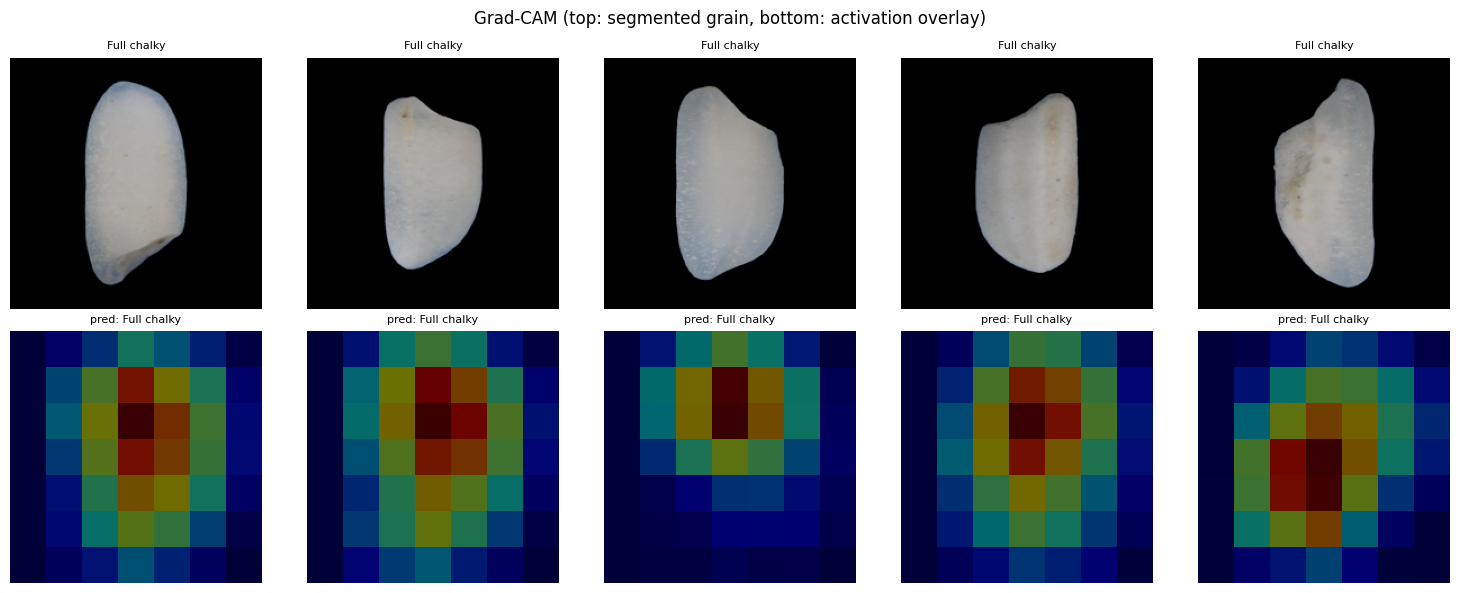

In [10]:
import torch.nn.functional as F
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.acts = None; self.grads = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, m, i, o): self.acts = o.detach()
    def _bwd(self, m, gi, go): self.grads = go[0].detach()
    def __call__(self, x, cls=None):
        out = self.model(x)
        if cls is None: cls = out.argmax(1)
        self.model.zero_grad()
        out[range(len(cls)), cls].sum().backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1))
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam.cpu().numpy(), cls.cpu().numpy()

def show_gradcam(result, n=5):
    model, classes, te = result["model"], result["classes"], result["test"]
    cam = GradCAM(model, model.layer4)
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for j in range(n):
        path, label, _ = te[j]
        img = Image.open(path).convert("RGB")
        x = eval_tf(img).unsqueeze(0).to(device)
        heat, pred = cam(x)
        base = np.array(img.resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)))
        h = np.uint8(255 * heat[0])
        axes[0, j].imshow(base); axes[0, j].set_title(label, fontsize=8); axes[0, j].axis("off")
        axes[1, j].imshow(base); axes[1, j].imshow(h, cmap="jet", alpha=0.45)
        axes[1, j].set_title(f"pred: {classes[pred[0]]}", fontsize=8); axes[1, j].axis("off")
    fig.suptitle("Grad-CAM (top: segmented grain, bottom: activation overlay)")
    fig.tight_layout()
    fig.savefig(SUP_DIR / "gradcam_examples.png", dpi=200, bbox_inches="tight")
    plt.show()

show_gradcam(res5, n=5)

---
### Outputs produced
* `Checkpoints/models/*.pth` — every trained model (headline, per-fold, per-seed, per-arch), reused on later runs
* `Outputs/supervised/confusion_5class.png`, `confusion_6class.png`
* `Outputs/supervised/per_class_metrics_5class.csv`, `per_class_metrics_6class.csv`
* `Outputs/supervised/architecture_comparison_5class.csv`
* `Outputs/supervised/gradcam_examples.png`

**Numbers to transfer into the manuscript**
* Headline = the **5-fold CV mean ± std** (Section 3).
* Report the **6-class** accuracy alongside the 5-class one and describe where its
  confusion concentrates (Section 2) — this is the direct answer to the partial-chalky
  reviewers.
* Add the **per-class precision/recall/F1 table** and **ROC-AUC** (Section 2), and the
  **architecture-comparison table** (Section 5).

A few-tenths change from the originally-reported 96.1% is expected after the rename and
re-run; because it sits inside the CV std, it strengthens rather than weakens the
reproducibility claim — just make sure every number and figure in the paper comes from
this one canonical run.

## 7.Plotting from saved results

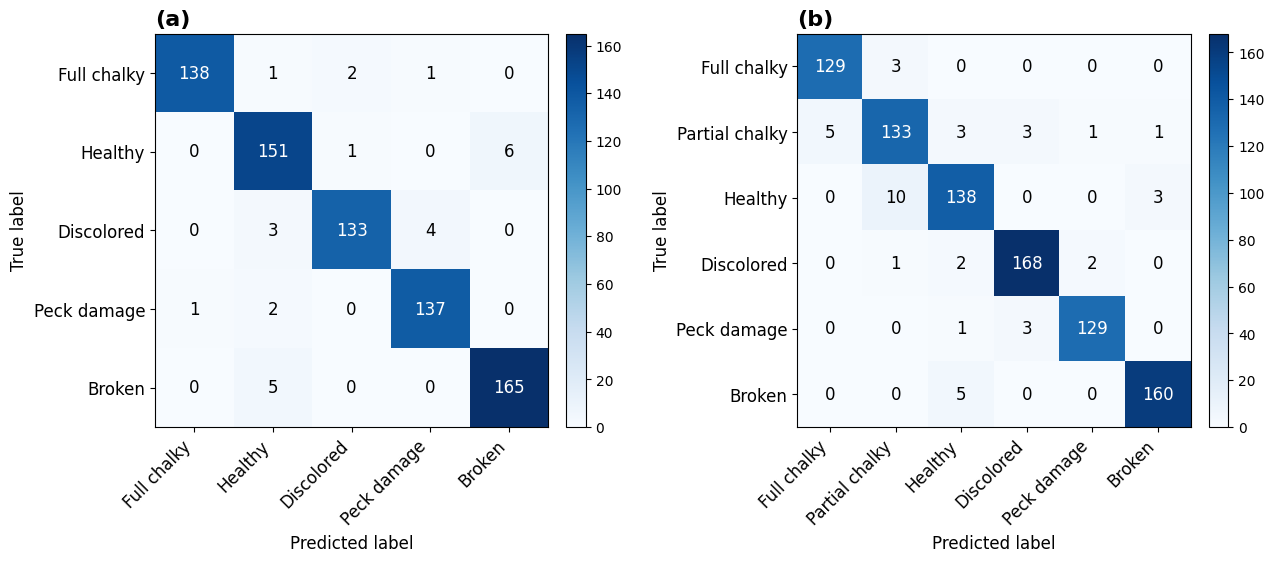

saved Outputs\supervised\confusion_pair.png


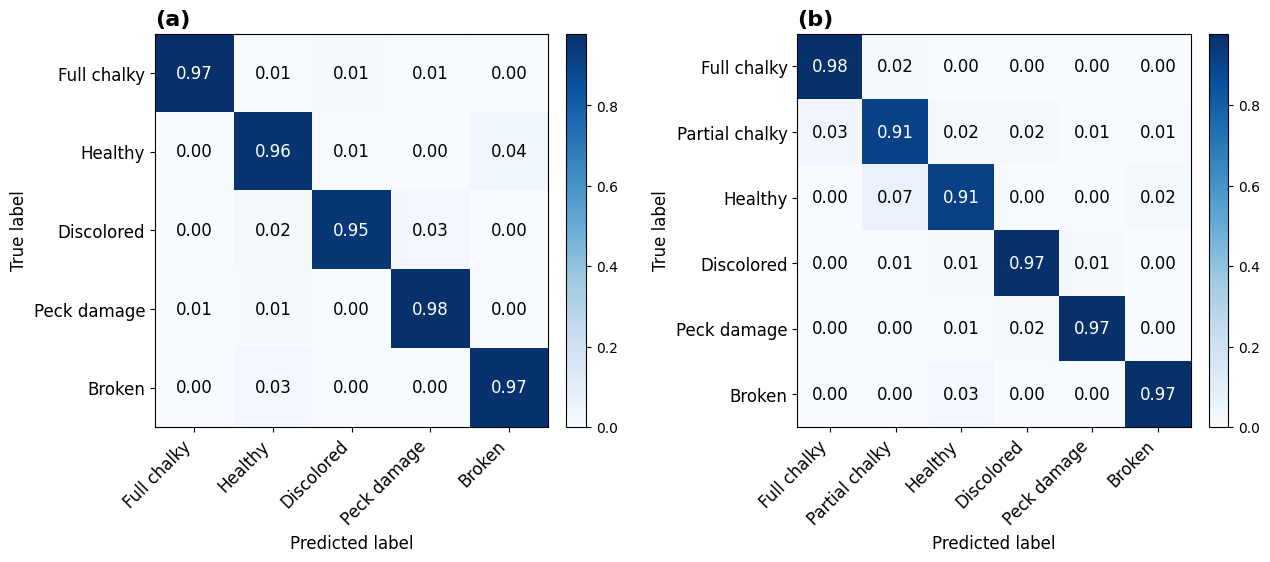

saved Outputs\supervised\confusion_pair_norm.png


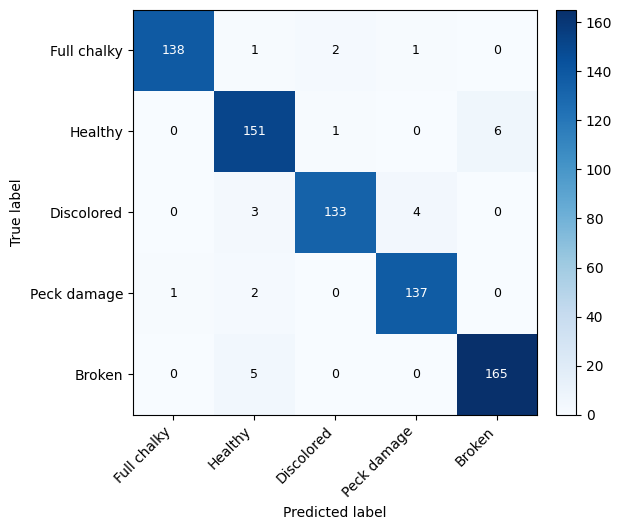

saved Outputs\supervised\confusion_5class.png


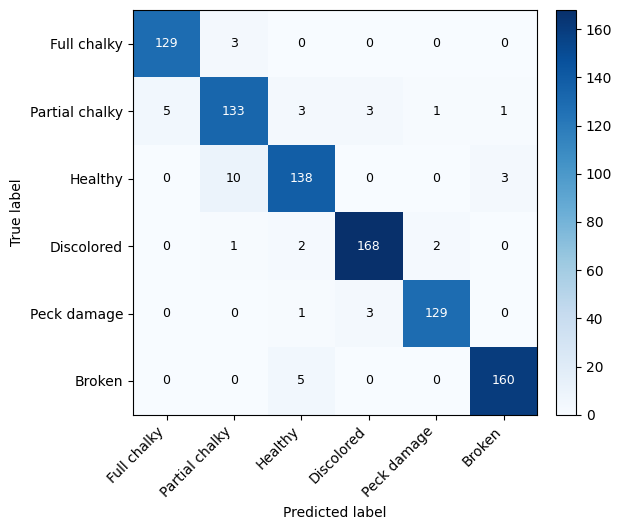

saved Outputs\supervised\confusion_6class.png


In [11]:
# ===== Plotting from saved results (no retraining) =====
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion(tag, classes, normalize=False):
    Y = np.load(SUP_DIR / f"y_true_{tag}.npy")
    P = np.load(SUP_DIR / f"y_pred_{tag}.npy")
    cm = confusion_matrix(Y, P, labels=range(len(classes)))
    disp = cm.astype(float)
    if normalize:
        disp = disp / disp.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6.2, 5.4))
    im = ax.imshow(disp, cmap="Blues", vmin=0, vmax=disp.max())
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right"); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    thr = disp.max() / 2
    for i in range(len(classes)):
        for j in range(len(classes)):
            txt = f"{disp[i,j]:.2f}" if normalize else f"{cm[i,j]:d}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if disp[i,j] > thr else "black", fontsize=9)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = SUP_DIR / f"confusion_{tag}{'_norm' if normalize else ''}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show(); print("saved", out)
def plot_confusion_pair(normalize=False):
    specs = [("5class", rc.CLASSES_5, "(a)"),
             ("6class", rc.CLASSES_6, "(b)")]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
    for ax, (tag, classes, label) in zip(axes, specs):
        Y = np.load(SUP_DIR / f"y_true_{tag}.npy")
        P = np.load(SUP_DIR / f"y_pred_{tag}.npy")
        cm = confusion_matrix(Y, P, labels=range(len(classes)))
        disp = cm.astype(float)
        if normalize:
            disp = disp / disp.sum(axis=1, keepdims=True)
        im = ax.imshow(disp, cmap="Blues", vmin=0, vmax=disp.max())
        ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha="right"); ax.set_yticklabels(classes)
        ax.set_xlabel("Predicted label", fontsize=12); ax.set_ylabel("True label", fontsize=12)
        ax.tick_params(axis='both', labelsize=12)
        thr = disp.max() / 2
        for i in range(len(classes)):
            for j in range(len(classes)):
                txt = f"{disp[i,j]:.2f}" if normalize else f"{cm[i,j]:d}"
                ax.text(j, i, txt, ha="center", va="center",
                        color="white" if disp[i,j] > thr else "black", fontsize=12)
        # panel label above each subplot, left-aligned
        ax.set_title(label, loc="left", fontsize=16, fontweight="bold")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = SUP_DIR / f"confusion_pair{'_norm' if normalize else ''}.png"
    out_pdf = SUP_DIR / f"confusion_pair{'_norm' if normalize else ''}.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
    plt.show(); print("saved", out)

plot_confusion_pair(normalize=False)   # counts — cite this one
plot_confusion_pair(normalize=True)    # row-normalized — clearer per-class recall
# the one cited for Reviewer 1 (5-class, counts):
plot_confusion("5class", rc.CLASSES_5, normalize=False)
# 6-class version for the partial-chalky argument:
plot_confusion("6class", rc.CLASSES_6, normalize=False)



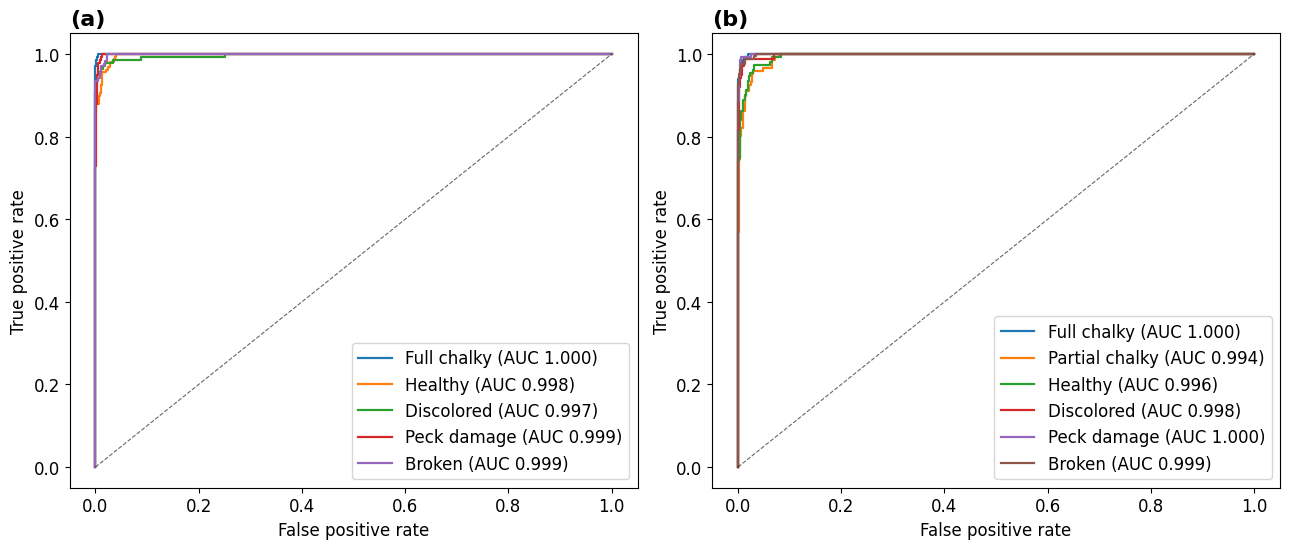

saved Outputs\supervised\roc_pair.png
saved Outputs\supervised\roc_pair.pdf


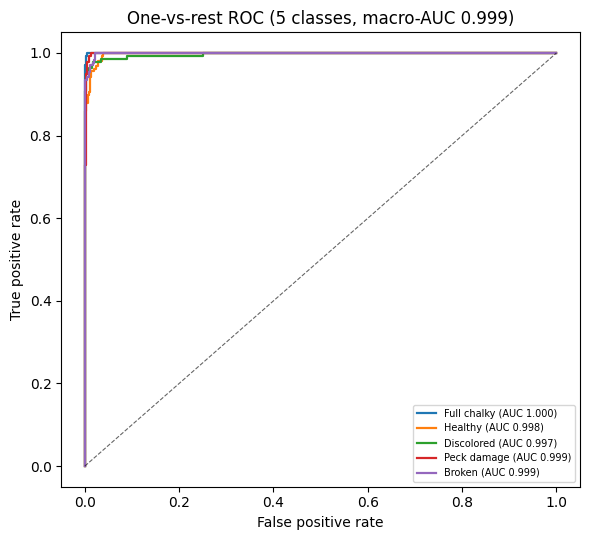

saved Outputs\supervised\roc_5class.png


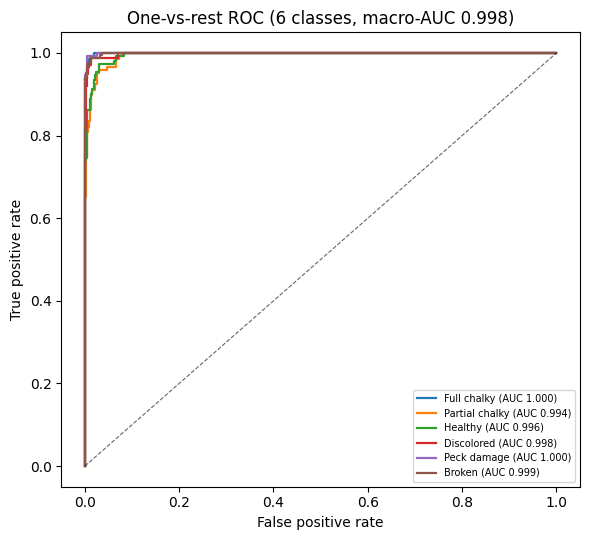

saved Outputs\supervised\roc_6class.png


In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np, matplotlib.pyplot as plt

def plot_roc(tag, classes):
    Y = np.load(SUP_DIR / f"y_true_{tag}.npy")
    PR = np.load(SUP_DIR / f"y_prob_{tag}.npy")          # shape (N, n_classes)
    Yb = label_binarize(Y, classes=range(len(classes)))

    fig, ax = plt.subplots(figsize=(6, 5.5))
    for i, cname in enumerate(classes):
        fpr, tpr, _ = roc_curve(Yb[:, i], PR[:, i])
        ax.plot(fpr, tpr, lw=1.6, label=f"{cname} (AUC {auc(fpr, tpr):.3f})")
    # macro-average line
    macro = np.mean([auc(*roc_curve(Yb[:, i], PR[:, i])[:2]) for i in range(len(classes))])
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.6)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"One-vs-rest ROC ({len(classes)} classes, macro-AUC {macro:.3f})")
    ax.legend(fontsize=7, loc="lower right")
    fig.tight_layout()
    out = SUP_DIR / f"roc_{tag}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight"); plt.show(); print("saved", out)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_pair():
    specs = [("5class", rc.CLASSES_5, "(a)"), ("6class", rc.CLASSES_6, "(b)")]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
    for ax, (tag, classes, label) in zip(axes, specs):
        Y  = np.load(SUP_DIR / f"y_true_{tag}.npy")
        PR = np.load(SUP_DIR / f"y_prob_{tag}.npy")
        Yb = label_binarize(Y, classes=range(len(classes)))
        for i, cname in enumerate(classes):
            fpr, tpr, _ = roc_curve(Yb[:, i], PR[:, i])
            ax.plot(fpr, tpr, lw=1.6, label=f"{cname} (AUC {auc(fpr, tpr):.3f})")
        ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.6)
        ax.set_xlabel("False positive rate", fontsize=12); ax.set_ylabel("True positive rate", fontsize=12 )
        ax.tick_params(axis='both', labelsize=12)
        ax.set_title(label, loc="left", fontsize=16, fontweight="bold")  # panel tag only
        ax.legend(fontsize=12, loc="lower right")
    fig.tight_layout()
    out = SUP_DIR / "roc_pair.png"
    out_pdf = SUP_DIR / "roc_pair.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight"); plt.show(); print("saved", out)
    fig.savefig(out_pdf, dpi=300, bbox_inches="tight"); print("saved", out_pdf)

plot_roc_pair()
plot_roc("5class", rc.CLASSES_5)
plot_roc("6class", rc.CLASSES_6)

## 5 fold plots

In [12]:
import torch
print("device var:", device, type(device))
print("cuda avail:", torch.cuda.is_available())
m = rc.build_model("resnet18", 5)
print("model device before:", next(m.parameters()).device)
m = m.to(device)
print("model device after :", next(m.parameters()).device)

device var: cuda <class 'str'>
cuda avail: True
model device before: cpu
model device after : cuda:0


In [ ]:
# ===== FAST CV: cached images + GPU (device already works — do NOT change it) =====
import numpy as np, hashlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

FORCE_RETRAIN = True
TAG, CLASSES = "5class", rc.CLASSES_5     # 6-class: "6class", rc.CLASSES_6
cfg.BATCH_SIZE = 32                       # T1000 4GB: safe at 224px; drop to 16 if you hit OOM

# ---------- 1. resize each image once to a cache (THE speed fix) ----------
CACHE = Path(SUP_DIR) / "img_cache_512"; CACHE.mkdir(parents=True, exist_ok=True)

def _cache_path(src):
    return CACHE / (hashlib.md5(str(src).encode()).hexdigest() + ".png")

def _cache_row(r, short=512):
    src = r[0]; dst = _cache_path(src)
    if not dst.exists():
        im = Image.open(src); im.draft("RGB", (short, short))   # fast JPEG downscale-on-decode
        im = im.convert("RGB"); w, h = im.size
        s = short / min(w, h)
        im.resize((round(w * s), round(h * s))).save(dst)       # keep aspect ratio
    return (str(dst),) + tuple(r[1:])

pool = prepare_pool(CLASSES)
cached_pool = [_cache_row(r) for r in tqdm(pool, desc="caching images (one-time)")]

# ---------- 2. CV with per-epoch history + out-of-fold confusion matrix ----------
def cross_validate(classes, pool, arch="resnet18", tag="5class", epochs=None):
    y = np.array([classes.index(r[1]) for r in pool])
    g = np.array([r[2] for r in pool])
    sgkf = StratifiedGroupKFold(n_splits=cfg.NUM_FOLDS, shuffle=True, random_state=cfg.SEED)
    accs, f1s, fold_hists, oof_t, oof_p = [], [], [], [], []
    for k, (tr_idx, va_idx) in enumerate(tqdm(sgkf.split(y, y, g), total=cfg.NUM_FOLDS, desc="CV folds")):
        assert set(g[tr_idx]).isdisjoint(set(g[va_idx]))
        tr = [pool[i] for i in tr_idx]; va = [pool[i] for i in va_idx]
        ckpt = CKPT_DIR / f"{arch}_{tag}_cv_fold{k+1}.pth"
        model, _, hist = train_one(tr, va, classes, arch=arch, epochs=epochs, verbose=False, ckpt_path=ckpt)
        P, _, Y = evaluate(model, make_loader(va, classes, eval_tf, shuffle=False))
        accs.append(accuracy_score(Y, P)); f1s.append(f1_score(Y, P, average="macro"))
        fold_hists.append(hist); oof_t.append(Y); oof_p.append(P)
        print(f"  fold {k+1}: acc={accs[-1]:.4f}  macroF1={f1s[-1]:.4f}")
    accs, f1s = np.array(accs), np.array(f1s)
    cm = confusion_matrix(np.concatenate(oof_t), np.concatenate(oof_p), labels=range(len(classes)))
    print(f"\n[{tag}] CV acc = {accs.mean()*100:.2f}% ± {accs.std()*100:.2f}%"
          f"   macroF1 = {f1s.mean()*100:.2f}% ± {f1s.std()*100:.2f}%")
    return accs, f1s, fold_hists, cm

accs, f1s, fold_hists, cm = cross_validate(CLASSES, cached_pool, tag=TAG)

# save first, so the numbers survive even if plotting hiccups
np.save(SUP_DIR / f"cv_histories_{TAG}.npy", np.array(fold_hists, dtype=object), allow_pickle=True)
np.save(SUP_DIR / f"cv_cm_{TAG}.npy", cm)

# ---------- 3. diagnostics ----------
def cv_diagnostics(cm, classes):
    cm = np.asarray(cm, float); tot = cm.sum()
    tp = np.diag(cm); fn = cm.sum(1) - tp; fp = cm.sum(0) - tp; tn = tot - tp - fn - fp
    return tp/(tp+fn), tn/(tn+fp), tp.sum()/tot, (tp/(tp+fn)).mean()

sens, spec, acc, bal = cv_diagnostics(cm, CLASSES)
print(f"\n===== CV diagnostics ({TAG}) — update the manuscript to these =====")
print(f"{'class':15s}{'recall/sens':>12s}{'specificity':>13s}")
for c, s, sp in zip(CLASSES, sens, spec): print(f"{c:15s}{s:12.4f}{sp:13.4f}")
print(f"\nCV accuracy (fold mean) = {accs.mean()*100:.2f}% ± {accs.std()*100:.2f}%")
print(f"overall (micro) accuracy = {acc*100:.2f}%   error rate = {(1-acc)*100:.2f}%")
print(f"min sensitivity = {sens.min():.4f}   min specificity = {spec.min():.4f}")
print(f"balanced accuracy (macro recall) = {bal:.4f}")
di, pe = CLASSES.index("Discolored"), CLASSES.index("Peck damage")
print(f"Discolored->Peck = {cm[di,pe]:.0f}   Peck->Discolored = {cm[pe,di]:.0f}")

# ---------- 4. Figure 9 ----------
TRAIN_C, VAL_C, BAND_A = "#1b3a5b", "#4e9ac6", 0.20
def _stack(h, key):
    a = np.vstack([np.asarray([e[key] for e in fh], float) for fh in h]); return a.mean(0), a.std(0), np.arange(1, a.shape[1]+1)
def _curve(ax, h, tk, vk, ylab, title):
    tm, ts, ep = _stack(h, tk); vm, vs, _ = _stack(h, vk)
    ax.plot(ep, tm, color=TRAIN_C, lw=2, label="Train"); ax.fill_between(ep, tm-ts, tm+ts, color=TRAIN_C, alpha=BAND_A)
    ax.plot(ep, vm, color=VAL_C, lw=2, ls="--", label="Validation"); ax.fill_between(ep, vm-vs, vm+vs, color=VAL_C, alpha=BAND_A)
    ax.fill_between([], [], [], color="0.6", alpha=BAND_A, label=r"$\pm$1 SD")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylab); ax.set_title(title, fontweight="bold"); ax.legend(frameon=False, fontsize=8); ax.margins(x=0)

assert isinstance(fold_hists[0][0], dict), "train_one isn't logging per-epoch dicts — apply the epoch-loop edit and rerun."
disp = cm.astype(float); disp /= disp.sum(1, keepdims=True)
fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.15], wspace=0.35, hspace=0.55)
axa, axb, axc = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0]), fig.add_subplot(gs[:,1])
_curve(axa, fold_hists, "train_loss", "val_loss", "Cross-Entropy Loss", "(a) Training and Validation Loss")
_curve(axb, fold_hists, "train_acc", "val_acc", "Accuracy", "(b) Training and Validation Accuracy")
im = axc.imshow(disp, cmap="Blues", vmin=0, vmax=1)
axc.set_title(f"(c) Confusion Matrix ({cfg.NUM_FOLDS}-Fold Cross-Validation)", fontweight="bold")
axc.set_xticks(range(len(CLASSES))); axc.set_yticks(range(len(CLASSES)))
axc.set_xticklabels(CLASSES, rotation=45, ha="right"); axc.set_yticklabels(CLASSES)
axc.set_xlabel("Predicted Label"); axc.set_ylabel("True Label")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axc.text(j, i, f"{disp[i,j]:.2f}", ha="center", va="center", color="white" if disp[i,j] > .5 else "black", fontsize=9)
fig.colorbar(im, ax=axc, fraction=0.046, pad=0.04)
fig.savefig(SUP_DIR / f"cv_results_{TAG}.pdf", bbox_inches="tight")
fig.savefig(SUP_DIR / f"cv_results_{TAG}.png", dpi=200, bbox_inches="tight"); plt.show()

5-class pool: 5000 imgs -> {'Full chalky': 1000, 'Healthy': 1000, 'Discolored': 1000, 'Peck damage': 1000, 'Broken': 1000}


CV folds:  20%|██        | 1/5 [14:25<57:41, 865.43s/it]

  fold 1: acc=0.9640  macroF1=0.9640


CV folds:  40%|████      | 2/5 [28:14<42:12, 844.25s/it]

  fold 2: acc=0.9680  macroF1=0.9680


...

CV folds:  80%|████████  | 4/5 [58:44<14:51, 891.68s/it]

  fold 4: acc=0.9620  macroF1=0.9619


CV folds: 100%|██████████| 5/5 [1:13:07<00:00, 877.59s/it]

  fold 5: acc=0.9720  macroF1=0.9718

[5class] CV acc = 96.62% ± 0.35%   macroF1 = 96.61% ± 0.35%

===== CV diagnostics (5class) — update the manuscript to these =====
class           recall/sens  specificity
Full chalky          0.9980       0.9952
Healthy              0.9610       0.9848
Discolored           0.9370       0.9930
Peck damage          0.9750       0.9930
Broken               0.9600       0.9918

CV accuracy (fold mean) = 96.62% ± 0.35%
overall (micro) accuracy = 96.62%   error rate = 3.38%
min sensitivity = 0.9370   min specificity = 0.9848
balanced accuracy (macro recall) = 0.9662


ValueError: 'Peck_damage' is not in list

In [15]:
import numpy as np
from pathlib import Path
for f in ["cv_histories_5class.npy", "cv_cm_5class.npy"]:
    p = Path(SUP_DIR) / f
    print(f, "exists:", p.exists())

cv_histories_5class.npy exists: True
cv_cm_5class.npy exists: True


In [16]:
di, pe = CLASSES.index("Discolored"), CLASSES.index("Peck damage")   # space, not underscore
print(f"Discolored->Peck = {cm[di,pe]:.0f}   Peck->Discolored = {cm[pe,di]:.0f}")

Discolored->Peck = 26   Peck->Discolored = 20


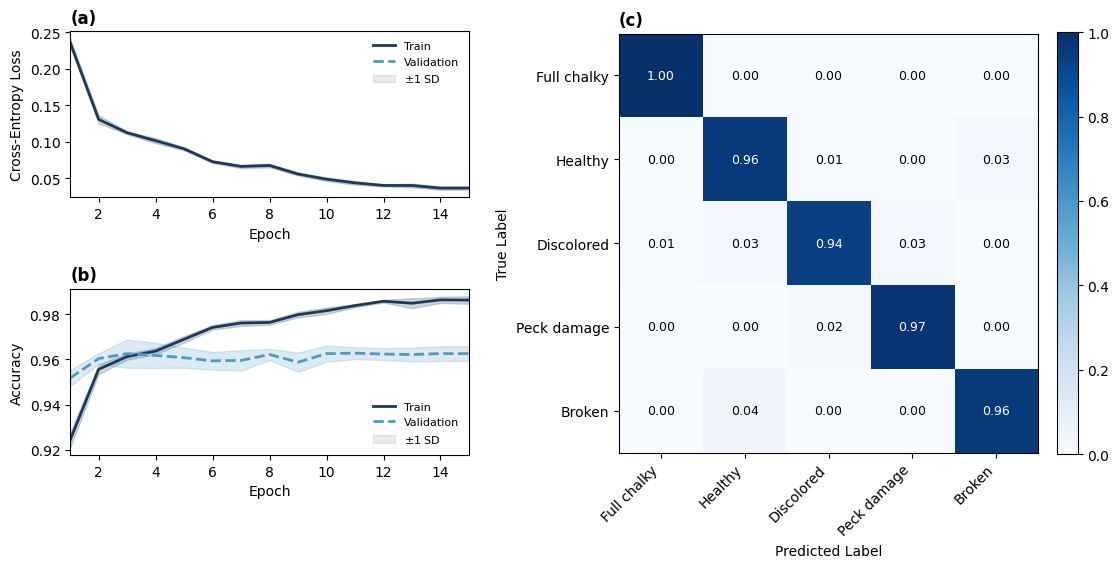

saved cv_results_5class.pdf / .png in Outputs\supervised


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from pathlib import Path

TAG, CLASSES = "5class", rc.CLASSES_5

# reload the saved results (no retraining)
fold_hists = list(np.load(Path(SUP_DIR) / f"cv_histories_{TAG}.npy", allow_pickle=True))
cm = np.load(Path(SUP_DIR) / f"cv_cm_{TAG}.npy")

TRAIN_C, VAL_C, BAND_A = "#1b3a5b", "#4e9ac6", 0.20
def _stack(h, key):
    a = np.vstack([np.asarray([e[key] for e in fh], float) for fh in h])
    return a.mean(0), a.std(0), np.arange(1, a.shape[1]+1)
def _curve(ax, h, tk, vk, ylab, title):
    tm, ts, ep = _stack(h, tk); vm, vs, _ = _stack(h, vk)
    ax.plot(ep, tm, color=TRAIN_C, lw=2, label="Train"); ax.fill_between(ep, tm-ts, tm+ts, color=TRAIN_C, alpha=BAND_A)
    ax.plot(ep, vm, color=VAL_C, lw=2, ls="--", label="Validation"); ax.fill_between(ep, vm-vs, vm+vs, color=VAL_C, alpha=BAND_A)
    ax.fill_between([], [], [], color="0.6", alpha=BAND_A, label=r"$\pm$1 SD")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylab); ax.set_title(title, fontweight="bold", loc="left"); ax.legend(frameon=False, fontsize=8); ax.margins(x=0)

disp = cm.astype(float); disp /= disp.sum(1, keepdims=True)
fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.15], wspace=0.35, hspace=0.55)
axa, axb, axc = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0]), fig.add_subplot(gs[:,1])
_curve(axa, fold_hists, "train_loss", "val_loss", "Cross-Entropy Loss", "(a)")
_curve(axb, fold_hists, "train_acc", "val_acc", "Accuracy", "(b)")
im = axc.imshow(disp, cmap="Blues", vmin=0, vmax=1)
axc.set_title("(c)", fontweight="bold", loc="left")
axc.set_xticks(range(len(CLASSES))); axc.set_yticks(range(len(CLASSES)))
axc.set_xticklabels(CLASSES, rotation=45, ha="right"); axc.set_yticklabels(CLASSES)
axc.set_xlabel("Predicted Label"); axc.set_ylabel("True Label")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axc.text(j, i, f"{disp[i,j]:.2f}", ha="center", va="center", color="white" if disp[i,j] > .5 else "black", fontsize=9)
fig.colorbar(im, ax=axc, fraction=0.046, pad=0.04)
fig.savefig(Path(SUP_DIR) / f"cv_results_{TAG}.pdf", bbox_inches="tight")
fig.savefig(Path(SUP_DIR) / f"cv_results_{TAG}.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved cv_results_" + TAG + ".pdf / .png in", SUP_DIR)